In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../../data/raw/kc_house_data.csv")
Cdata = data.copy()
data_cleaned = Cdata.copy()
print("Shape fillestare:", data_cleaned.shape)

Shape fillestare: (21613, 21)


In [2]:
data_cleaned["date"] = pd.to_datetime(data_cleaned["date"])
data_cleaned["sale_year"]  = data_cleaned["date"].dt.year
data_cleaned["sale_month"] = data_cleaned["date"].dt.month
data_cleaned["house_age_at_sale"] = data_cleaned["sale_year"] - data_cleaned["yr_built"]
data_cleaned["was_renovated"] = (data_cleaned["yr_renovated"] > 0).astype(int)
data_cleaned["years_since_renovation"] = np.where(
    data_cleaned["yr_renovated"] > 0,
    data_cleaned["sale_year"] - data_cleaned["yr_renovated"],
    0
)
data_cleaned[["date","sale_year","sale_month","yr_built","house_age_at_sale",
              "yr_renovated","was_renovated","years_since_renovation"]].head()

,date,sale_year,sale_month,yr_built,house_age_at_sale,yr_renovated,was_renovated,years_since_renovation
0,2014-10-13,2014,10,1955,59,0,0,0
1,2014-12-09,2014,12,1951,63,1991,1,23
2,2015-02-25,2015,2,1933,82,0,0,0
3,2014-12-09,2014,12,1965,49,0,0,0
4,2015-02-18,2015,2,1987,28,0,0,0


In [3]:
before_rows = data_cleaned.shape[0]

data_cleaned = data_cleaned[
    (data_cleaned["bedrooms"] > 0) &
    (data_cleaned["bedrooms"] <= 10) &
    (data_cleaned["bathrooms"] > 0)
].copy()

after_rows = data_cleaned.shape[0]
print("Rows before:", before_rows)
print("Rows after: ", after_rows)
print("Removed:    ", before_rows - after_rows)

Rows before: 21613
Rows after:  21595
Removed:     18


In [4]:
before_rows = data_cleaned.shape[0]

negative_age  = data_cleaned["house_age_at_sale"] < 0
negative_reno = data_cleaned["years_since_renovation"] < 0
invalid_rows  = negative_age | negative_reno

print("Rows me house_age_at_sale < 0:",       negative_age.sum())
print("Rows me years_since_renovation < 0:",  negative_reno.sum())

data_cleaned = data_cleaned[~invalid_rows].copy()

after_rows = data_cleaned.shape[0]
print("Rows before:", before_rows)
print("Rows after: ", after_rows)
print("Removed:    ", before_rows - after_rows)

Rows me house_age_at_sale < 0: 12
Rows me years_since_renovation < 0: 6
Rows before: 21595
Rows after:  21577
Removed:     18


In [5]:
property_groups = data_cleaned["id"].copy()

data_cleaned = data_cleaned.drop(columns=["id", "date"])
print("Kolonat pas largimit:", list(data_cleaned.columns))
print("Shape:", data_cleaned.shape)

Kolonat pas largimit: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'house_age_at_sale', 'was_renovated', 'years_since_renovation']
Shape: (21577, 24)


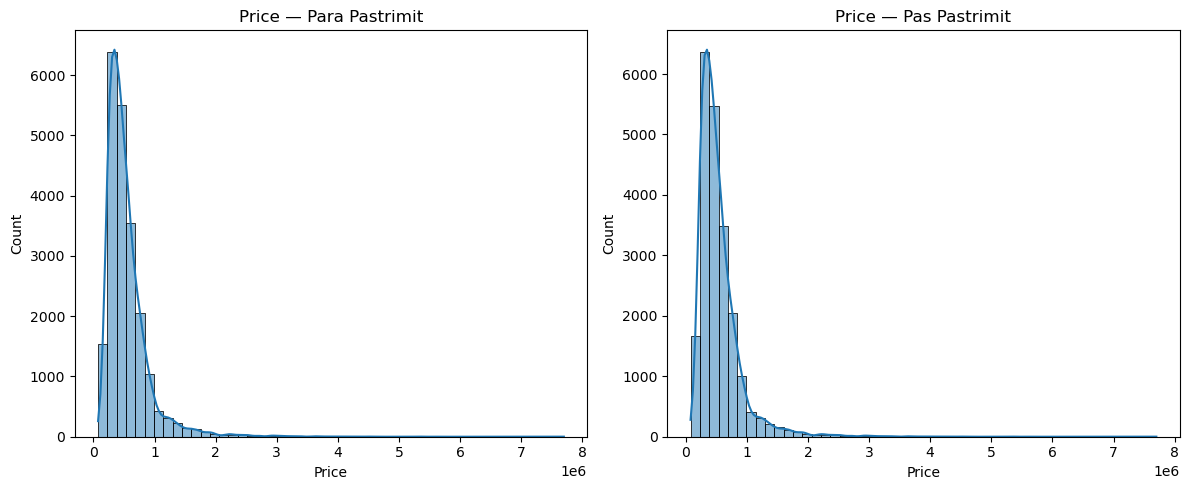

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(Cdata["price"], bins=50, kde=True)
plt.title("Price — Para Pastrimit")
plt.xlabel("Price")

plt.subplot(1, 2, 2)
sns.histplot(data_cleaned["price"], bins=50, kde=True)
plt.title("Price — Pas Pastrimit")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

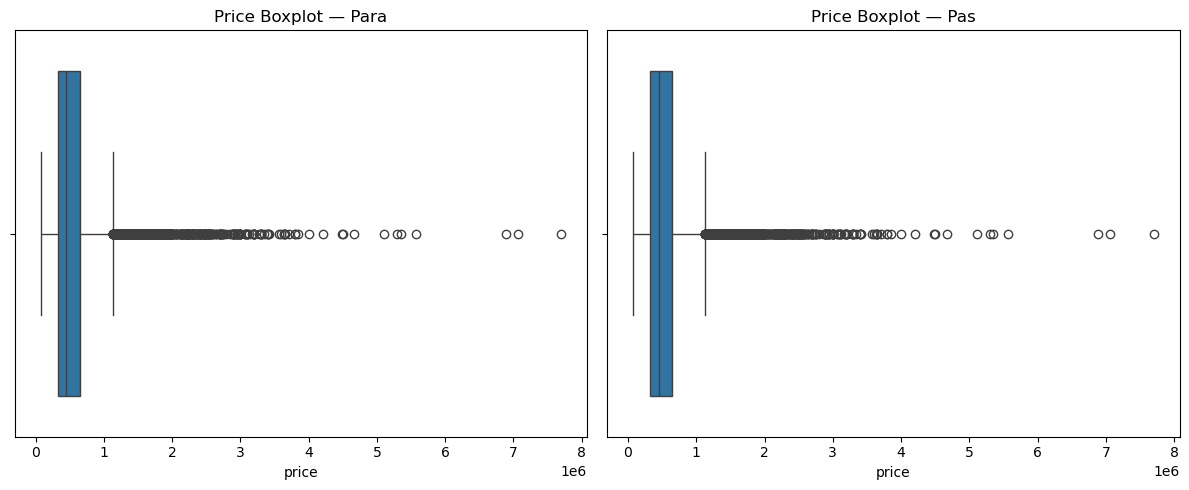

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=Cdata["price"])
plt.title("Price Boxplot — Para")

plt.subplot(1, 2, 2)
sns.boxplot(x=data_cleaned["price"])
plt.title("Price Boxplot — Pas")
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("../../data/processed", exist_ok=True)
data_cleaned.to_csv("../../data/processed/data_cleaned.csv", index=False)
property_groups.to_csv("../../data/processed/property_groups.csv", index=False)

print("Shape finale:", data_cleaned.shape)
print("Skedarët e ruajtur:")
print("  ../../data/processed/data_cleaned.csv")
print("  ../../data/processed/property_groups.csv")

Shape finale: (21577, 24)
Skedarët e ruajtur:
  ../../data/processed/data_cleaned.csv
  ../../data/processed/property_groups.csv
